In [ ]:
# ============================================
# PART 1 — IMPORTS & SETUP
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid", palette="viridis")


In [ ]:
# ============================================
# PART 2 — LOAD DATASET
# ============================================

try:
    data = pd.read_csv("sample_data/bankura_wheat_detailed.csv")
    print("✅ Dataset loaded successfully!")
    display(data.head())
except FileNotFoundError:
    print("❌ Error: CSV not found.")


✅ Dataset loaded successfully!


,Year,District,Wheat_Yield_t_ha,year,week_1_precip,week_1_LST,week_2_precip,week_2_LST,week_3_precip,week_3_LST,...,fortnight_7_precip,fortnight_7_LST,fortnight_8_precip,fortnight_8_LST,fortnight_9_precip,fortnight_9_LST,fortnight_10_precip,fortnight_10_LST,fortnight_11_precip,fortnight_11_LST
0,2001,Bankura,2.425,2001,0.000000,30.205143,0.000000,29.356571,0.0,26.550571,...,0.000000,30.830929,1.479643,31.752143,0.000000,36.067286,2.765214,34.706714,0.743833,35.792083
1,2002,Bankura,2.470,2002,0.003000,29.035714,0.000000,27.504571,0.0,26.874571,...,0.495214,28.736929,0.441286,32.055286,0.771071,34.149000,0.925786,19.060929,0.960583,33.695417
2,2003,Bankura,2.582,2003,0.000000,27.376286,0.000000,27.356571,0.0,26.379143,...,0.561214,26.870357,0.000000,30.876857,4.167000,30.839071,0.067786,32.530429,1.760750,34.737500
3,2004,Bankura,2.688,2004,0.004571,27.358286,0.000429,26.208143,0.0,25.116571,...,0.051214,28.055214,0.000500,33.127643,0.022143,34.405071,1.806857,36.295714,2.129846,34.975538
4,2005,Bankura,2.648,2005,0.009714,27.176143,0.000000,27.300429,0.0,26.503714,...,1.336500,29.370714,0.056000,31.440429,2.330786,33.169857,0.781714,33.096429,0.438750,35.231917


In [ ]:
# ============================================
# PART 3 — IDENTIFY FEATURE COLUMNS
# ============================================

TARGET = "Wheat_Yield_t_ha"

exclude_cols = ["Year", "District", TARGET, "year"]

feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Identified {len(feature_cols)} feature columns.")
feature_cols


Identified 66 feature columns.


['week_1_precip',
 'week_1_LST',
 'week_2_precip',
 'week_2_LST',
 'week_3_precip',
 'week_3_LST',
 'week_4_precip',
 'week_4_LST',
 'week_5_precip',
 'week_5_LST',
 'week_6_precip',
 'week_6_LST',
 'week_7_precip',
 'week_7_LST',
 'week_8_precip',
 'week_8_LST',
 'week_9_precip',
 'week_9_LST',
 'week_10_precip',
 'week_10_LST',
 'week_11_precip',
 'week_11_LST',
 'week_12_precip',
 'week_12_LST',
 'week_13_precip',
 'week_13_LST',
 'week_14_precip',
 'week_14_LST',
 'week_15_precip',
 'week_15_LST',
 'week_16_precip',
 'week_16_LST',
 'week_17_precip',
 'week_17_LST',
 'week_18_precip',
 'week_18_LST',
 'week_19_precip',
 'week_19_LST',
 'week_20_precip',
 'week_20_LST',
 'week_21_precip',
 'week_21_LST',
 'week_22_precip',
 'week_22_LST',
 'fortnight_1_precip',
 'fortnight_1_LST',
 'fortnight_2_precip',
 'fortnight_2_LST',
 'fortnight_3_precip',
 'fortnight_3_LST',
 'fortnight_4_precip',
 'fortnight_4_LST',
 'fortnight_5_precip',
 'fortnight_5_LST',
 'fortnight_6_precip',
 'fortnigh

In [ ]:
# ============================================
# PART 4 — TIME-SERIES TRANSFORMATION
# ============================================

# Detect weeks automatically (week_1, week_2, ...)
# features = [col for col in data.columns if col not in exclude_cols]
original_features = feature_cols.copy()

weeks = sorted(list(set([
    int(col.split('_')[1]) for col in feature_cols if "week_" in col
])))

num_weeks = len(weeks)
print(f"Detected {num_weeks} weeks.")

# ✅ CORRECT FIX
features_per_week = 2

print(f"Detected {features_per_week} features per week.")

# Build 3D dataset: (samples, time_steps, features)
X_seq = []

for _, row in data.iterrows():
    seq = []
    for w in weeks:
        seq.append([
            row[f"week_{w}_precip"],
            row[f"week_{w}_LST"]
        ])
    X_seq.append(seq)

X_seq = np.array(X_seq)
y = data[TARGET].values

print("Final LSTM input shape:", X_seq.shape)


Detected 22 weeks.
Detected 2 features per week.
Final LSTM input shape: (24, 22, 2)


In [ ]:
# ============================================
# PART 5 — TRAIN-TEST SPLIT & SCALING
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

# reshape to 2D for scaling
X_train_r = X_train.reshape(-1, features_per_week)
X_test_r  = X_test.reshape(-1, features_per_week)

scaler.fit(X_train_r)

X_train_scaled = scaler.transform(X_train_r).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_r).reshape(X_test.shape)

print("Scaling completed.")


Scaling completed.


In [ ]:
print("Expected flat size:", num_weeks * features_per_week)
print("Actual flat size:", X_train_scaled.reshape(X_train_scaled.shape[0], -1).shape[1])

Expected flat size: 44
Actual flat size: 44


In [ ]:
# ============================================
# PART 6 — BUILD LSTM MODEL
# ============================================

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(num_weeks, features_per_week)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 22, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,657 (119.75 KB)

 Trainable params: 30,657 (119.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("Total elements:", X_train_scaled.size)


X_train_scaled shape: (19, 22, 2)
Total elements: 836


In [ ]:
# Collapse last dimension so shape becomes (19, 44)
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

print(X_train_flat.shape)


(19, 44)


In [ ]:
num_features = X_train_flat.shape[1]

X_train_lstm = X_train_flat.reshape(X_train_flat.shape[0], 1, num_features)
X_test_lstm = X_test_flat.reshape(X_test_flat.shape[0], 1, num_features)

print(X_train_lstm.shape)


(19, 1, 44)


In [ ]:
print("X_train_lstm shape =", X_train_lstm.shape)
print("y_train shape =", y_train.shape)


X_train_lstm shape = (19, 1, 44)
y_train shape = (19,)


In [ ]:
print(X_train_lstm.shape)   # must be (19, 1, 44)
num_features = X_train_lstm.shape[2]


(19, 1, 44)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([

    LSTM(64, return_sequences=True, input_shape=(22, 2)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 22, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,657 (119.75 KB)

 Trainable params: 30,657 (119.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# PART 7 — TRAIN MODEL
# ============================================

# Early stopping callback
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss',
    mode='min'
)

# 🔥 Use correct input (already 3D for LSTM)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 5.8643 - mae: 2.4111 - val_loss: 5.5252 - val_mae: 2.3321
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 5.6398 - mae: 2.3653 - val_loss: 5.3338 - val_mae: 2.2905
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 5.4919 - mae: 2.3323 - val_loss: 5.1315 - val_mae: 2.2458
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 5.2381 - mae: 2.2791 - val_loss: 4.9222 - val_mae: 2.1987
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 5.0319 - mae: 2.2320 - val_loss: 4.7020 - val_mae: 2.1481
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 4.8494 - mae: 2.1912 - val_loss: 4.4809 - val_mae: 2.0960
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 4.7252 - mae: 2.1645 - val_loss: 4.2562 - val_mae: 2.0416
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 4.5339 - mae: 2.1162 - val_loss: 4.0186 - val_mae: 1.9825
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 4.2285 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1074 - mae: 0.2653

📈 LSTM Evaluation Results:
MAE: 0.2653
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


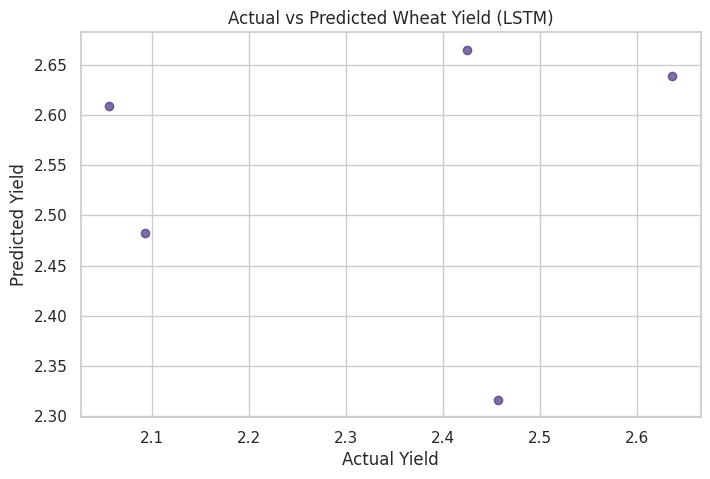

In [ ]:
# ============================================
# PART 8 — EVALUATE MODEL
# ============================================

# Evaluate model using the correctly reshaped test data
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=1)

print("\n📈 LSTM Evaluation Results:")
print(f"MAE: {mae:.4f}")

# Predict on test data
y_pred = model.predict(X_test_scaled)

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Wheat Yield (LSTM)")
plt.show()



📈 LSTM Evaluation Results:
MAE: 0.2653
MSE: 0.1074
R2 Score: -1.1350


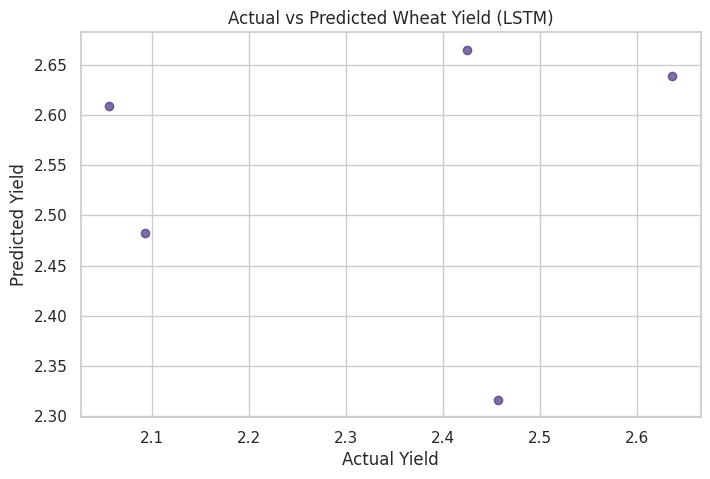

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate model using the correctly reshaped test data
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n📈 LSTM Evaluation Results:")
print(f"MAE: {mae:.4f}")

# Predict on test data
y_pred = model.predict(X_test_scaled, verbose=0)

# Calculate MSE and R2 Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Wheat Yield (LSTM)")
plt.show()

# **XAI EXPLANATION MODULE**

**SHAP**

In [ ]:
!pip install shap lime

In [ ]:
print("num_weeks:", num_weeks)
print("features_per_week:", features_per_week)
print("Expected flat size:", num_weeks * features_per_week)
print("Actual flat size:", X_train_flat.shape[1])

num_weeks: 22
features_per_week: 2
Expected flat size: 44
Actual flat size: 44


In [ ]:
test = X_train_scaled[:2]

print("Input shape:", test.shape)

out = model.predict(test, verbose=0)

print("Output:", out)

Input shape: (2, 22, 2)


Output: [[2.4624517]
 [2.292875 ]]


In [ ]:
import shap
import numpy as np

X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat  = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

def model_wrapper(X):
    X = np.array(X)

    if len(X.shape) == 1:
        X = X.reshape(1, -1)

    X_reshaped = X.reshape(X.shape[0], num_weeks, features_per_week)

    preds = model.predict(X_reshaped, verbose=0)

    return preds.reshape(-1, 1)

background = X_train_flat[:10]

explainer = shap.KernelExplainer(model_wrapper, background)

X_sample = X_test_flat[:5]

shap_values = explainer.shap_values(X_sample)

print("✅ SHAP finally working!")

  0%|          | 0/5 [00:00<?, ?it/s]

✅ SHAP finally working!


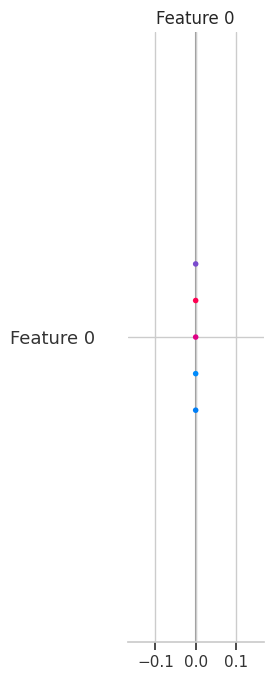

In [ ]:
# Flatten for visualization
X_sample_flat = X_sample.reshape(X_sample.shape[0], -1)

shap.summary_plot(
    shap_values,
    X_sample_flat
)

**LIME**

In [ ]:
from lime import lime_tabular

# Flatten data for LIME
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat  = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_flat,
    mode='regression'
)

# Explain one sample
i = 0

exp = explainer.explain_instance(
    X_test_flat[i],
    lambda x: model.predict(x.reshape(-1, num_weeks, features_per_week)),
    num_features=10
)

exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


**PFI**

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, num_weeks, features_per_week):
        self.model = model
        self.num_weeks = num_weeks
        self.features_per_week = features_per_week

    def fit(self, X, y):
        return self  # already trained

    def predict(self, X):
        X = np.array(X)

        if len(X.shape) == 1:
            X = X.reshape(1, -1)

        X_reshaped = X.reshape(-1, self.num_weeks, self.features_per_week)

        preds = self.model.predict(X_reshaped, verbose=0)
        return preds.flatten()

X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

wrapped_model = KerasWrapper(model, num_weeks, features_per_week)

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    estimator=wrapped_model,
    X=X_test_flat,
    y=y_test,
    scoring="neg_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = result.importances_mean

print("✅ PFI computed!")

✅ PFI computed!


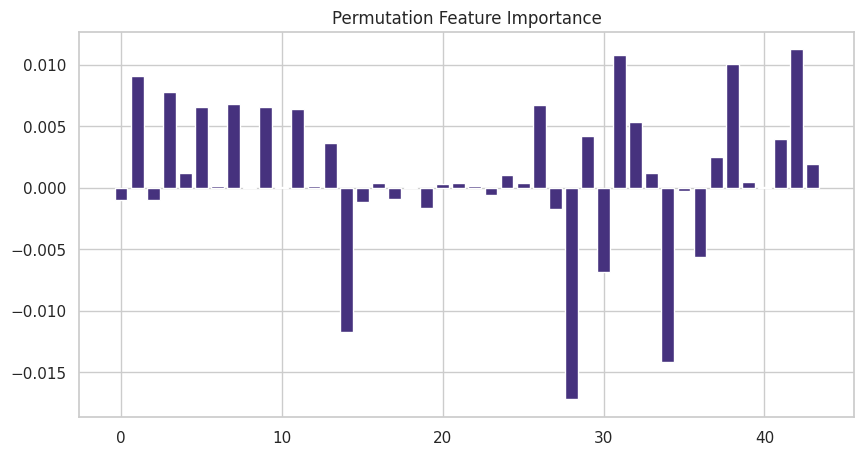

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Permutation Feature Importance")
plt.show()

**PDF**

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class KerasPDPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, num_weeks, features_per_week):
        self.model = model
        self.num_weeks = num_weeks
        self.features_per_week = features_per_week

    def fit(self, X, y=None):
        # Required attributes for sklearn
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True
        return self

    def predict(self, X):
        X = np.array(X)

        if len(X.shape) == 1:
            X = X.reshape(1, -1)

        X_reshaped = X.reshape(-1, self.num_weeks, self.features_per_week)

        preds = self.model.predict(X_reshaped, verbose=0)
        return preds.flatten()

# Flatten data
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

# Wrap model
wrapped_model = KerasPDPWrapper(model, num_weeks, features_per_week)

# Fit wrapper (VERY IMPORTANT)
wrapped_model.fit(X_test_flat, y_test)

KerasPDPWrapper(features_per_week=2,
                model=<Sequential name=sequential_6, built=True>, num_weeks=22)

In [ ]:
feature_names = []
for w in range(1, num_weeks+1):
    feature_names.append(f"week_{w}_precip")
    feature_names.append(f"week_{w}_LST")

In [ ]:
import numpy as np

def compute_pdp(model, X, feature_index, grid_points=20):
    X = X.copy()

    values = np.linspace(
        X[:, feature_index].min(),
        X[:, feature_index].max(),
        grid_points
    )

    pdp = []

    for v in values:
        X_temp = X.copy()
        X_temp[:, feature_index] = v

        X_reshaped = X_temp.reshape(-1, num_weeks, features_per_week)
        preds = model.predict(X_reshaped, verbose=0)

        pdp.append(preds.mean())

    return values, pdp

In [ ]:
feature_index = 0  # try different features

values, pdp = compute_pdp(model, X_test_flat, feature_index)

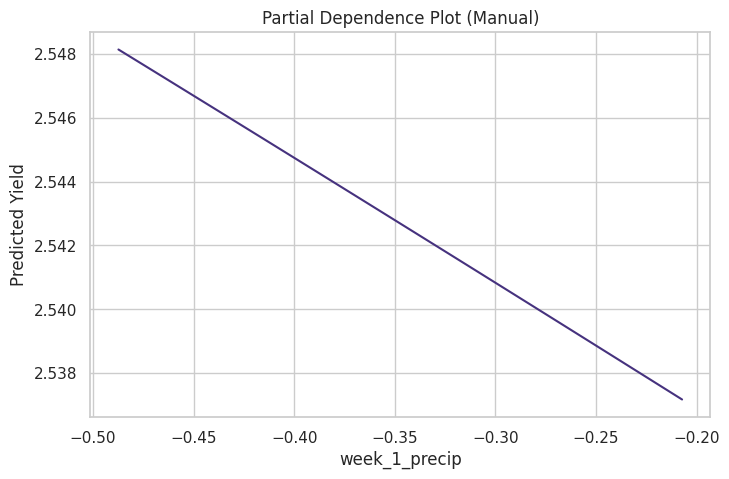

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(values, pdp)
plt.xlabel(f"Feature {feature_index}")
plt.ylabel("Predicted Yield")
plt.xlabel(feature_names[feature_index])
plt.title("Partial Dependence Plot (Manual)")
plt.show()

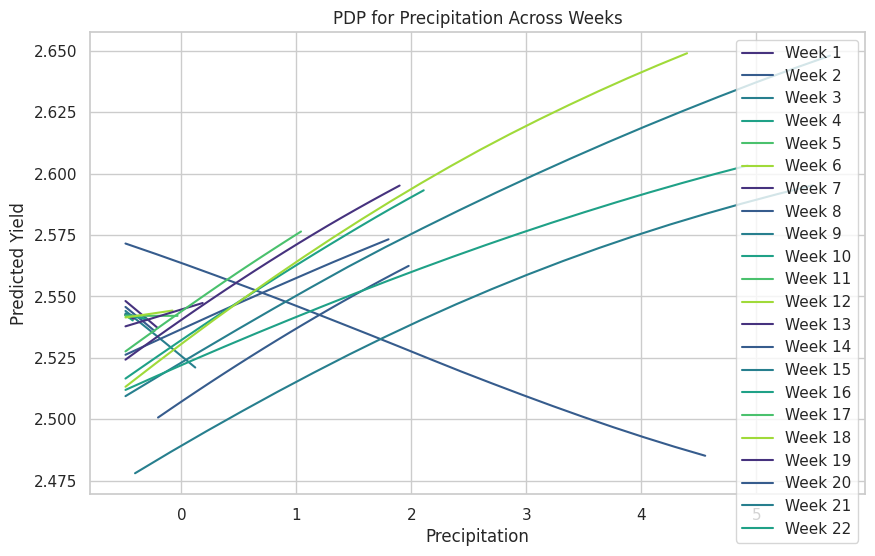

In [ ]:
plt.figure(figsize=(10,6))

for w in range(22):
    idx = 2*w  # precip indices
    values, pdp = compute_pdp(model, X_test_flat, idx)
    plt.plot(values, pdp, label=f"Week {w+1}")

plt.legend()
plt.title("PDP for Precipitation Across Weeks")
plt.xlabel("Precipitation")
plt.ylabel("Predicted Yield")
plt.show()

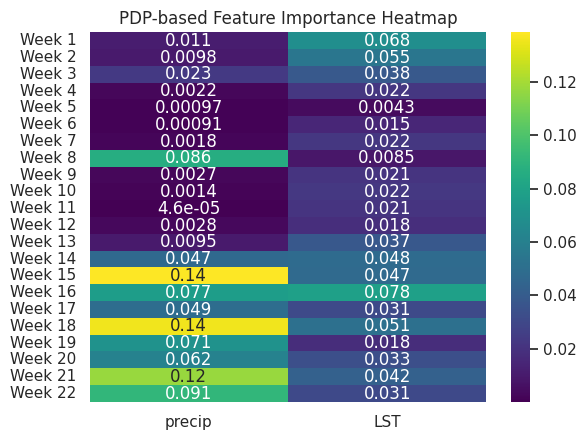

In [ ]:
importance = []

for i in range(X_test_flat.shape[1]):
    values, pdp = compute_pdp(model, X_test_flat, i)
    importance.append(max(pdp) - min(pdp))  # variation = importance

importance = np.array(importance).reshape(num_weeks, features_per_week)

import seaborn as sns

sns.heatmap(importance, annot=True, cmap="viridis",
            xticklabels=["precip", "LST"],
            yticklabels=[f"Week {i+1}" for i in range(num_weeks)])

plt.title("PDP-based Feature Importance Heatmap")
plt.show()